In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from bokeh.io import output_file, show
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, Span, Toggle, Slider, CustomJS, Div
from bokeh.layouts import column, row

In [86]:
df = pd.read_csv("D:\Code\K PROJECT\data\Becker_Keefe_2022\AS_TM_GNSS_Combined\AS_TM_GNSS_8_10_10.csv")
# Kiểm tra số lượng cột
print("Số lượng cột:", len(df.columns))

# (Tuỳ chọn) In ra tên các cột
print("Tên các cột:")
print(df.columns.tolist())

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\XPS 9520\AppData\Local\Temp\ipykernel_33420\2661741616.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("D:\Code\K PROJECT\data\Becker_Keefe_2022\AS_TM_GNSS_Combined\AS_TM_GNSS_8_10_10.csv")


Số lượng cột: 31
Tên các cột:
['Unnamed: 0', 'Time', 'Accel.X', 'Accel.Y', 'Accel.Z', 'Grav.X', 'Grav.Y', 'Grav.Z', 'L.Accel.X', 'L.Accel.Y', 'L.Accel.Z', 'Gyro.X', 'Gyro.Y', 'Gyro.Z', 'Mag.X', 'Mag.Y', 'Mag.Z', 'Orient.Z', 'Orient.X', 'Orient.Y', 'Sound', 'Dur.MS', 'AS.Time', 'X', 'Element', 'Cam.Lat', 'Cam.Long', 'Cab.Lat', 'Cab.Long', 'Boom.Lat', 'Boom.Long']


In [87]:

# Giả sử bạn đã đọc file vào df
df['AS.Time'] = df['AS.Time'].astype(str).str.strip()

# Xem 10 giá trị đầu tiên
print(df['AS.Time'].head(10))

# Xem 20 giá trị khác nhau để tìm định dạng lạ
print(df['AS.Time'].dropna().unique()[:20])

0    5:27:30.884
1    5:27:30.984
2    5:27:31.084
3    5:27:31.184
4    5:27:31.283
5    5:27:31.384
6    5:27:31.483
7    5:27:31.584
8    5:27:31.684
9    5:27:31.783
Name: AS.Time, dtype: object
['5:27:30.884' '5:27:30.984' '5:27:31.084' '5:27:31.184' '5:27:31.283'
 '5:27:31.384' '5:27:31.483' '5:27:31.584' '5:27:31.684' '5:27:31.783'
 '5:27:31.884' '5:27:31.984' '5:27:32.084' '5:27:32.184' '5:27:32.283'
 '5:27:32.384' '5:27:32.484' '5:27:32.584' '5:27:32.684' '5:27:32.783']


In [88]:
# Chuyển sang datetime đúng định dạng
df['AS.Time'] = pd.to_datetime('1900-01-01 ' + df['AS.Time'], format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')
df['AS.Time'] = df['AS.Time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Ho_Chi_Minh')
# Tạo dataframe mới gồm 7 cột mong muốn
columns_needed = ['Accel.X', 'Accel.Y', 'Accel.Z', 'Gyro.X', 'Gyro.Y', 'Gyro.Z', 'AS.Time']
df_subset = df[columns_needed].copy()

# Đổi tên cột dễ đọc
df_subset.rename(columns={
    'Accel.X': 'accel_X',
    'Accel.Y': 'accel_Y',
    'Accel.Z': 'accel_Z',
    'Gyro.X': 'gyro_X',
    'Gyro.Y': 'gyro_Y',
    'Gyro.Z': 'gyro_Z',
    'AS.Time': 'timestamp'
}, inplace=True)      

In [89]:
df_subset['timestamp'].isna().sum() # Kiểm tra số giá trị NaT trong df mới
df_subset['timestamp'].is_monotonic_increasing
df_subset = df_subset.sort_values(by='timestamp')
df_subset



,accel_X,accel_Y,accel_Z,gyro_X,gyro_Y,gyro_Z,timestamp
0,-2.4669,4.0188,8.3778,-0.1415,-0.1385,-0.0495,1900-01-01 12:34:30.884000+07:07
1,-2.8692,3.4824,7.7694,-0.5521,0.1012,-0.0851,1900-01-01 12:34:30.984000+07:07
2,-0.1054,1.9543,6.9982,-1.3655,-0.3952,0.0182,1900-01-01 12:34:31.084000+07:07
3,2.7303,-0.7568,10.5860,-0.9511,0.1896,0.3596,1900-01-01 12:34:31.184000+07:07
4,2.1172,3.3818,9.9441,0.1403,-2.5870,0.0576,1900-01-01 12:34:31.283000+07:07
...,...,...,...,...,...,...,...
189771,0.1341,7.1659,6.9982,0.9138,0.9029,-0.3596,1900-01-01 17:50:47.983000+07:07
189772,-1.7148,8.3586,5.7576,0.8291,0.7468,-0.0352,1900-01-01 17:50:48.084000+07:07
189773,-1.0730,8.2820,5.1493,0.1127,0.1167,-0.0848,1900-01-01 17:50:48.184000+07:07
189774,-1.2646,8.3969,5.6954,0.3433,0.5497,-0.0837,1900-01-01 17:50:48.283000+07:07


In [90]:
df_subset.describe()

,accel_X,accel_Y,accel_Z,gyro_X,gyro_Y,gyro_Z
count,189776.000000,189776.000000,189776.000000,189776.000000,189776.000000,189776.000000
mean,0.734262,9.877739,-1.742492,0.000548,-0.000276,-0.000299
std,1.573262,1.343218,2.170226,0.090147,0.160463,0.067873
min,-156.955200,-101.783500,-61.173600,-7.124200,-9.579300,-3.801800
25%,-0.297000,9.522600,-3.156600,-0.028100,-0.034300,-0.015400
50%,0.704100,9.996800,-2.035800,0.000200,0.000300,-0.000800
75%,1.786700,10.423100,-0.416700,0.029100,0.039100,0.013800
max,13.718700,27.772600,26.651800,9.270700,16.265000,9.922000


In [91]:
# Sao chép df_subset để tránh lỗi SettingWithCopyWarning
df_no_outliers = df_subset.copy()
# Tính Norm của Accel và Gyro
df_no_outliers['accel_norm'] = np.sqrt(df_no_outliers['accel_X']**2 + df_no_outliers['accel_Y']**2 + df_no_outliers['accel_Z']**2)
df_no_outliers['gyro_norm'] = np.sqrt(df_no_outliers['gyro_X']**2 + df_no_outliers['gyro_Y']**2 + df_no_outliers['gyro_Z']**2)
# --- BẮT ĐẦU KHỬ OUTLIERS ---

# 1. Xác định ngưỡng phân vị (ví dụ: 0.99)
#    Chúng ta chỉ quan tâm đến outliers ở "đầu trên" (giá trị quá cao)
accel_high_threshold = df_no_outliers['accel_norm'].quantile(0.99)
gyro_high_threshold = df_no_outliers['gyro_norm'].quantile(0.99)

# (Tùy chọn: Nếu bạn cũng muốn cắt "đầu dưới")
# accel_low_threshold = df_no_outliers['accel_norm'].quantile(0.01)
# gyro_low_threshold = df_no_outliers['gyro_norm'].quantile(0.01)

print(f"Ngưỡng Accel (99%): {accel_high_threshold:.2f}")
print(f"Ngưỡng Gyro (99%): {gyro_high_threshold:.2f}")

# 2. Lọc DataFrame
#    Giữ lại các hàng (rows) NẰM DƯỚI cả hai ngưỡng cao
df_no_outliers = df_no_outliers[
    (df_no_outliers['accel_norm'] < accel_high_threshold) &
    (df_no_outliers['gyro_norm'] < gyro_high_threshold)
]

# (Tùy chọn: Nếu bạn dùng cả ngưỡng dưới)
# df_no_outliers = df_no_outliers[
#     (df_no_outliers['accel_norm'] < accel_high_threshold) &
#     (df_no_outliers['gyro_norm'] < gyro_high_threshold) &
#     (df_no_outliers['accel_norm'] > accel_low_threshold) &
#     (df_no_outliers['gyro_norm'] > gyro_low_threshold)
# ]

print(f"\nSố lượng hàng ban đầu: {len(df_subset)}")
print(f"Số lượng hàng sau khi khử outliers: {len(df_no_outliers)}")
print(f"Đã loại bỏ: {len(df_subset) - len(df_no_outliers)} hàng.")

Ngưỡng Accel (99%): 13.01
Ngưỡng Gyro (99%): 0.47

Số lượng hàng ban đầu: 189776
Số lượng hàng sau khi khử outliers: 186033
Đã loại bỏ: 3743 hàng.


In [92]:
from sklearn.cluster import KMeans
import numpy as np
# Tạp feature tổng hợp
X_clean = df_no_outliers[['accel_norm', 'gyro_norm']]
# Tính Kmean
kmeans_clean = KMeans(n_clusters=3, random_state=42)
df_no_outliers['cluster'] = kmeans_clean.fit_predict(X_clean)
print(f'số vòng lặp kmeans đã chạy: {kmeans_clean.n_iter_}')
df_no_outliers.groupby('cluster')[['accel_norm', 'gyro_norm']].mean()


số vòng lặp kmeans đã chạy: 19


,accel_norm,gyro_norm
cluster,,
0,9.425342,0.103264
1,11.457765,0.107272
2,10.408891,0.092003


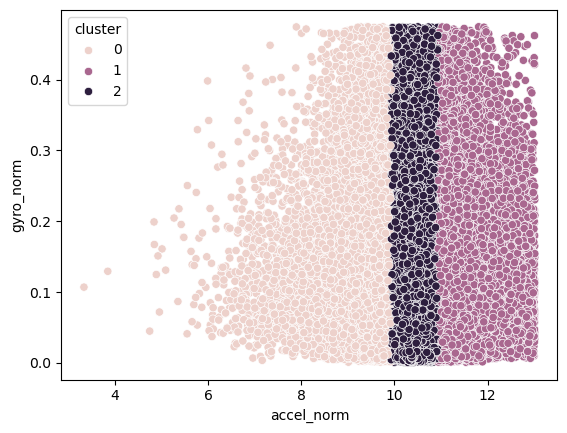

In [93]:
# 3. TRỰC QUAN HÓA LẠI
#    (Bây giờ bạn có thể dùng code plot, nó sẽ tự động đẹp
#     mà không cần zoom hay quantile_limit nữa)
import seaborn as sns
sns.scatterplot(data=df_no_outliers, x='accel_norm', y='gyro_norm', hue='cluster')
plt.savefig('kmeans_clean.png')